Author: Jake Grolig  
Course: Applied AI  
Project: Airline Delay Analysis

## Table of Contents

* Introduction
* Data Overview
* Preprocessing
* EDA
* Hypothesis Testing
* Insights
* Conclusion

# ✈️ Airline Delay Analysis

## 1. Introduction

### 📌 Problem Statement
Flight delays are a major challenge in the airline industry, impacting passengers, airline operations, and overall efficiency. Understanding the key factors that contribute to delays can help airlines make better operational decisions and improve customer satisfaction.

### 🎯 Objective
The goal of this project is to analyze airline performance data to identify patterns, trends, and key drivers of flight delays and cancellations.

### ❓ Key Questions
This analysis aims to answer the following questions:
- Do certain airlines experience more delays than others?
- Are specific airports more prone to delays?
- How do delays vary across different times (e.g., months)?
- Is there a relationship between flight volume and delays?
- What factors contribute most to cancellations?

### 📊 Approach
To answer these questions, we will:
1. Perform data cleaning and preprocessing  
2. Conduct exploratory data analysis (EDA)  
3. Apply statistical hypothesis testing  
4. Extract actionable insights and recommendations  

### 💼 Why This Matters
By identifying the root causes of delays, airlines can:
- Optimize scheduling and resource allocation  
- Reduce operational inefficiencies  
- Improve on-time performance  
- Enhance customer experience  

## 2. Data Overview 

### 2.1 Import Libraries
### 2.2 Load Dataset
### 2.3 Dataset Shape
### 2.4 Preview of Dataset
### 2.5 Column Information
### 2.6 Statistical Summary
### 2.7 Missing Values Check
### 2.8 Duplicate Values Check

___

### 2.1 Import Libraries

The following libraries are used for data manipulation, visualization, and statistical analysis throughout this project.

In [45]:
# Data manipulation

import pandas as pd
import numpy as np

# Data visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis

from scipy import stats

# Display settings

pd.set_option('display.max_columns', None)

### 2.2 Load Dataset

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [46]:
df = pd.read_csv(r"C:\Users\13015\Desktop\Airline Project\Airline_Delay_Dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 2.3 Dataset Shape

This section examines the number of rows and columns in the dataset.

In [47]:
print("Dataset Shape:", df.shape)

Dataset Shape: (92477, 19)


The dataset contains 92,477 rows and 19 columns, indicating a large dataset suitable for identifying trends and patterns related to airline delays and cancellations.

### 2.4 Preview of Dataset

The first few rows of the dataset are displayed below to understand the structure and contents of the data.

In [48]:
df.head()

,year,month,carrier,airport,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,CE-000,AT-00,89.0,13.0,2.25,1.60,3.16,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,CE-000,AT-01,62.0,10.0,1.97,0.04,0.57,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,CE-000,AT-02,62.0,10.0,2.73,1.18,1.80,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,CE-000,AT-03,66.0,12.0,3.69,2.27,4.47,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,CE-000,AT-04,92.0,22.0,7.76,0.00,2.96,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


### 2.5 Column Information

This section provides information about the dataset columns, including data types and non-null value counts.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92477 entries, 0 to 92476
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   year                 92477 non-null  int64  
 1   month                92477 non-null  int64  
 2   carrier              92477 non-null  object 
 3   airport              92477 non-null  object 
 4   arr_flights          92326 non-null  float64
 5   arr_del15            92139 non-null  float64
 6   carrier_ct           92326 non-null  float64
 7   weather_ct           92326 non-null  float64
 8   nas_ct               92326 non-null  float64
 9   security_ct          92326 non-null  float64
 10  late_aircraft_ct     92326 non-null  float64
 11  arr_cancelled        92326 non-null  float64
 12  arr_diverted         92326 non-null  float64
 13  arr_delay            92326 non-null  float64
 14  carrier_delay        92326 non-null  float64
 15  weather_delay        92326 non-null 

The dataset contains a mix of integer, float, and object data types. Numerical columns are primarily related to flight counts, delays, cancellations, and operational metrics, while object columns contain categorical information such as airline carriers and airport identifiers.

The dataset appears to contain a high number of non-null values overall, although some columns may require additional preprocessing to address missing values.

### 2.6 Statistical Summary

Descriptive statistics are used to summarize the numerical features within the dataset.

In [50]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,92477.000000,92477.000000,92326.000000,92139.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000,92326.000000
mean,2020.830661,6.227246,286.671393,56.781797,19.492678,2.140265,15.418681,0.175466,19.439746,8.404144,0.749659,3839.853790,1413.232513,225.316845,745.969077,8.286290,1447.043336
std,1.355159,3.397030,910.705200,164.614120,51.277935,7.486700,52.716249,0.825821,64.820558,53.407028,3.413909,12420.268609,4498.278697,877.550153,2980.517129,47.665554,5121.911398
min,2019.000000,1.000000,-21194.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,31.000000,5.000000,1.910000,0.000000,0.620000,0.000000,0.940000,0.000000,0.000000,256.000000,84.250000,0.000000,18.000000,0.000000,34.000000
50%,2021.000000,6.000000,82.000000,14.000000,5.310000,0.270000,2.940000,0.000000,3.650000,1.000000,0.000000,837.000000,312.000000,14.000000,108.000000,0.000000,231.000000
75%,2022.000000,9.000000,202.000000,38.000000,15.000000,1.750000,8.970000,0.000000,11.820000,4.000000,0.000000,2462.000000,1005.000000,138.000000,369.000000,0.000000,871.000000
max,2023.000000,12.000000,21873.000000,4142.000000,1293.910000,266.420000,1485.820000,58.690000,2069.070000,4951.000000,154.000000,438783.000000,162563.000000,27876.000000,97283.000000,3760.000000,227959.000000


The statistical summary provides insight into the distribution of numerical variables such as flight counts, delayed flights, cancellations, and delay durations.

Large variations between minimum, maximum, and mean values suggest the presence of operational differences across airports and airlines. Some variables may also contain outliers due to unusually high traffic or severe delay events.

### 2.7 Missing Values Check

This section identifies missing values within the dataset to determine whether data cleaning or imputation is necessary.

In [51]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

arr_del15              338
arr_flights            151
carrier_ct             151
weather_ct             151
nas_ct                 151
security_ct            151
late_aircraft_ct       151
arr_cancelled          151
arr_diverted           151
arr_delay              151
carrier_delay          151
weather_delay          151
nas_delay              151
security_delay         151
late_aircraft_delay    151
dtype: int64

Several columns contain missing values that may impact analysis if not addressed properly. These missing values will be handled during the data preprocessing stage using appropriate techniques such as imputation or removal where necessary.

### 2.8 Duplicate Values Check

Duplicate records are checked to ensure data quality and prevent redundant observations from affecting the analysis.

In [52]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


No duplicate rows were identified in the dataset, indicating that the records appear to be unique.

## 3. Data Cleaning & Preprocessing

### 3.1 Handle Missing Values
### 3.2 Remove Duplicate Records
### 3.3 Standardize Categorical Data
### 3.4 Feature Engineering

___

### 3.1 Handle Missing Values

Missing values can negatively impact analysis and statistical testing. In this section, numerical missing values are handled using median imputation to preserve the dataset while reducing the influence of outliers.

In [53]:
# Fill missing numerical values with median values

numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [54]:
df.isnull().sum()

year                   0
month                  0
carrier                0
airport                0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

Missing numerical values were successfully handled using median imputation. The median was selected instead of the mean because it is less sensitive to extreme values and outliers commonly found in operational airline data.

### 3.2 Remove Duplicate Records

Duplicate rows can distort statistical analysis and introduce bias into the dataset. This step removes duplicate observations to improve data quality.

In [55]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

In [56]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


While there were no duplicate rows present in the dataset of this project, this step is crucial to ensure the model performs this function on all datasets.

### 3.3 Standardize Categorical Data

Categorical columns are standardized to ensure consistency across values and prevent formatting inconsistencies from affecting analysis.

In [57]:
# Standardize carrier and airport columns

df['carrier'] = df['carrier'].str.strip().str.upper()

df['airport'] = df['airport'].str.strip().str.upper()

In [58]:
print(df['carrier'].unique()[:10])

print(df['airport'].unique()[:10])

['CE-000' 'CE-001' 'CE-002' 'CE-003' 'CE-004' 'CE-005' 'CE-006' 'CE-007'
 'CE-008' 'CE-009']
['AT-00' 'AT-01' 'AT-02' 'AT-03' 'AT-04' 'AT-05' 'AT-06' 'AT-07' 'AT-08'
 'AT-09']


Text formatting inconsistencies such as extra spaces and inconsistent capitalization were corrected to improve data consistency and prevent duplicate categorical representations.

### 3.4 Feature Engineering

New features are created to improve analysis and better capture operational performance metrics.

In [59]:
# Feature 1 - Delay Rate

df['delay_rate'] = df['arr_del15'] / df['arr_flights']

In [60]:
# Feature 2 - Cancellation Rate

df['cancel_rate'] = df['arr_cancelled'] / df['arr_flights']

In [61]:
df[['delay_rate', 'cancel_rate']].head()

,delay_rate,cancel_rate
0,0.146067,0.022472
1,0.161290,0.000000
2,0.161290,0.016129
3,0.181818,0.015152
4,0.239130,0.021739


Two new features were created to better measure airline operational performance:

- **Delay Rate:** Proportion of delayed flights relative to total arriving flights
- **Cancellation Rate:** Proportion of cancelled flights relative to total arriving flights

These engineered features allow for more meaningful comparisons across airlines and airports of different sizes.

## 4. Exploratory Data Analysis

### 4.1 Distribution of Flight Delays
### 4.2 Airlines with Highest Delay Rates
### 4.3 Airports with Highest Delay Rates
### 4.4 Monthly Delay Trends
### 4.5 Relationship Between Flight Volume and Delays
### 4.6 Cancellation Analysis

___

### 4.1 Distribution of Flight Delays

This visualization examines the distribution of delayed flights across the dataset to better understand overall delay patterns.

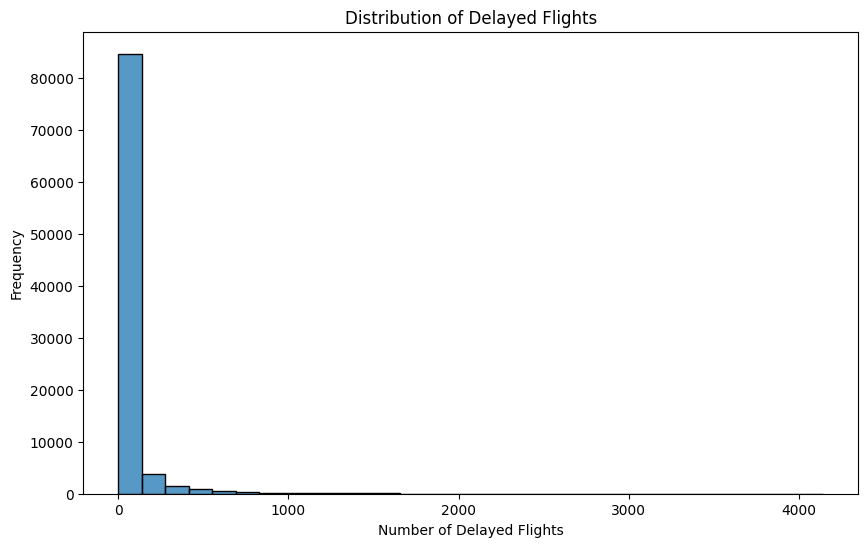

In [62]:
plt.figure(figsize=(10, 6))

sns.histplot(df['arr_del15'], bins=30)

plt.title('Distribution of Delayed Flights')
plt.xlabel('Number of Delayed Flights')
plt.ylabel('Frequency')

plt.show()

The distribution of delayed flights appears to be right-skewed, indicating that most observations contain relatively lower delay counts while a smaller number of observations experience significantly higher delays.

This suggests that severe delays may occur under specific operational conditions rather than being uniformly distributed across all flights.

### 4.2 Airlines with Highest Delay Rates

This analysis compares average delay rates across airline carriers to identify which airlines experience the highest operational delays.

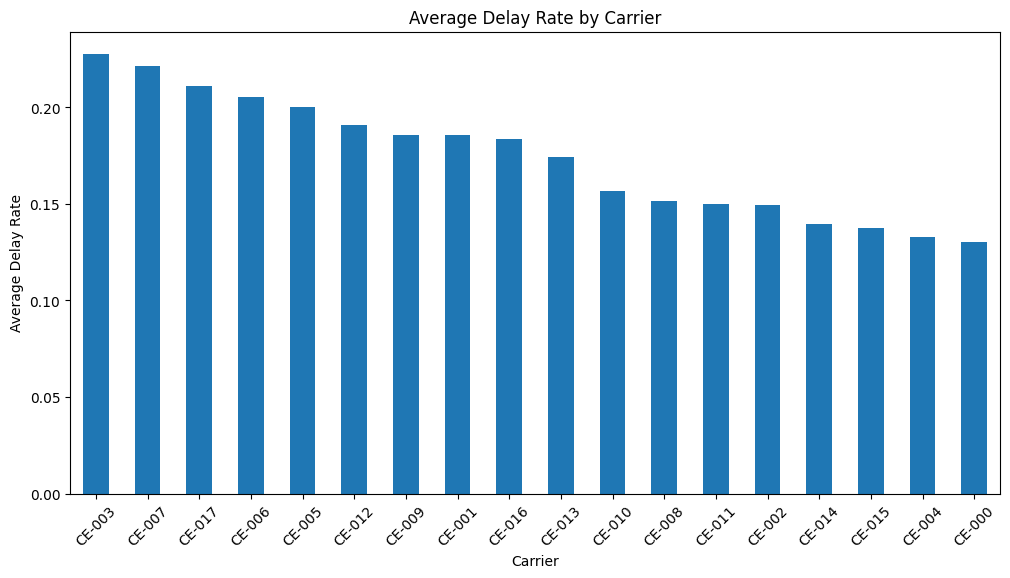

In [63]:
carrier_delay = df.groupby('carrier')['delay_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

carrier_delay.plot(kind='bar')

plt.title('Average Delay Rate by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Average Delay Rate')

plt.xticks(rotation=45)

plt.show()

Certain airlines demonstrate noticeably higher average delay rates than others, suggesting operational performance differences between carriers.

These differences may be influenced by factors such as route complexity, airport congestion, scheduling practices, or operational efficiency.

### 4.3 Airports with Highest Delay Rates

This section identifies airports with the highest average delay rates.

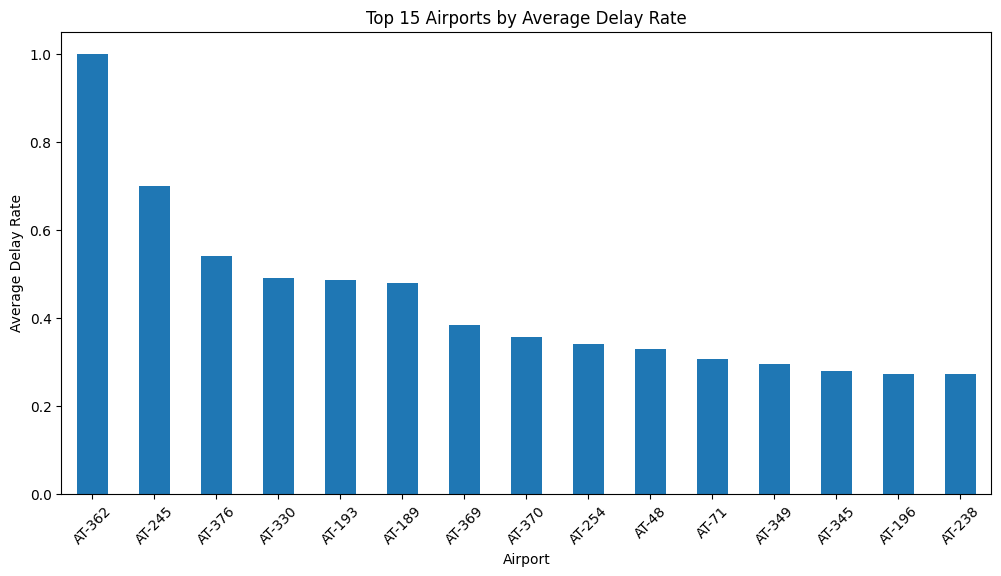

In [64]:
airport_delay = (
    df.groupby('airport')['delay_rate']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

airport_delay.plot(kind='bar')

plt.title('Top 15 Airports by Average Delay Rate')
plt.xlabel('Airport')
plt.ylabel('Average Delay Rate')

plt.xticks(rotation=45)

plt.show()

Several airports exhibit substantially higher delay rates than others. This may reflect differences in traffic volume, weather conditions, airport infrastructure, or operational congestion.

Large hub airports may experience increased delays due to higher flight density and scheduling complexity.

### 4.4 Monthly Delay Trends

This analysis explores how delay rates vary across different months to identify potential seasonal patterns.

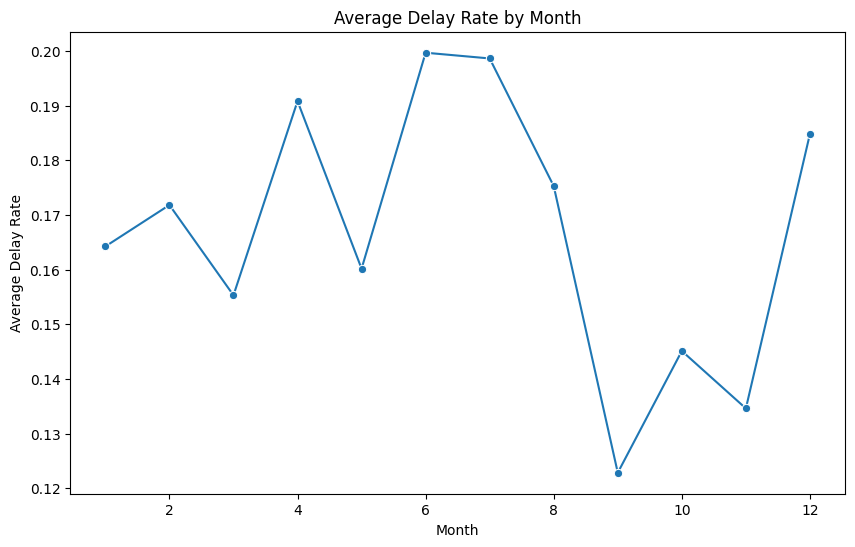

In [65]:
monthly_delay = df.groupby('month')['delay_rate'].mean()

plt.figure(figsize=(10, 6))

sns.lineplot(x=monthly_delay.index, y=monthly_delay.values, marker='o')

plt.title('Average Delay Rate by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay Rate')

plt.show()

Delay rates fluctuate throughout the year, suggesting possible seasonal effects on airline performance.

Higher delays during certain months may be associated with increased travel demand, adverse weather conditions, or holiday travel congestion.

### 4.5 Relationship Between Flight Volume and Delays

This visualization examines whether airports or airlines with higher flight volumes tend to experience higher delay rates.

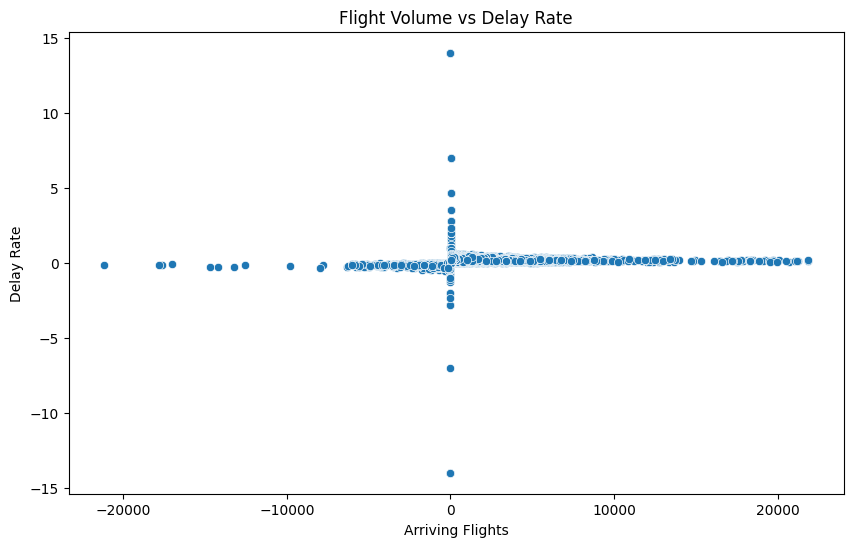

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['arr_flights'],
    y=df['delay_rate']
)

plt.title('Flight Volume vs Delay Rate')
plt.xlabel('Arriving Flights')
plt.ylabel('Delay Rate')

plt.show()

The relationship between flight volume and delay rate suggests that increased traffic may contribute to operational congestion and delays.

However, the relationship does not appear perfectly linear, indicating that additional operational factors likely influence delay performance.

### 4.6 Cancellation Analysis

This section examines cancellation patterns across the dataset.

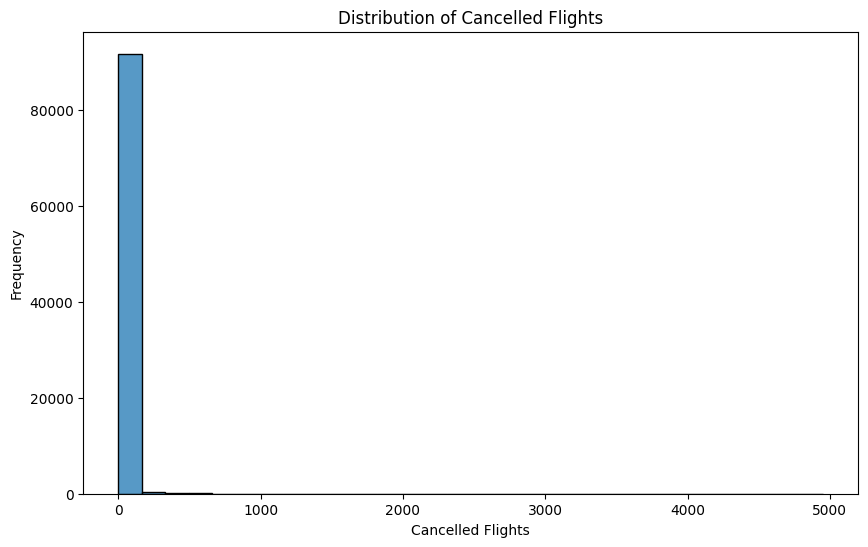

In [67]:
plt.figure(figsize=(10, 6))

sns.histplot(df['arr_cancelled'], bins=30)

plt.title('Distribution of Cancelled Flights')
plt.xlabel('Cancelled Flights')
plt.ylabel('Frequency')

plt.show()

Most observations contain relatively low cancellation counts, while a smaller number of observations experience significantly higher cancellations.

Extreme cancellation events may be linked to severe weather conditions, operational disruptions, or high-traffic travel periods.

## 5. Hypothesis Testing

### 5.1 Airline Delay Rate Comparison
### 5.2 Monthly Delay Variation
### 5.3 Flight Volume and Delay Relationship
### 5.4 Cancellation Rate and Delay Relationship

___

### 5.1 Airline Delay Rate Comparison

#### Business Question
Do different airline carrier groups experience significantly different delay rates?

#### Null Hypothesis (H₀)
There is no significant difference in average delay rates between airline carriers.

#### Alternative Hypothesis (H₁)
There is a significant difference in average delay rates between airline carriers.

### An independent t-test will be used to compare the average delay rates between two airline carriers.

In [68]:
# Select delay rates for two airlines

carrier_A = df[df['carrier'] == 'CE-011']['delay_rate']

carrier_B = df[df['carrier'] == 'CE-008']['delay_rate']

# Check sample sizes

print("CE-011 Sample Size:", len(carrier_A))
print("CE-008 Sample Size:", len(carrier_B))

# Perform independent t-test

t_stat, p_value = stats.ttest_ind(
    carrier_A,
    carrier_B,
    nan_policy='omit'
)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

print(f"Correlation Coefficient: {correlation:.4f}")


CE-011 Sample Size: 13213
CE-008 Sample Size: 7794
T-Statistic: -0.29026177522588065
P-Value: 0.7716188448923008
Correlation Coefficient: 0.3306


The p-value measures whether the observed difference in delay rates is statistically significant.

A significance level of 0.05 will be used:
- If p < 0.05 → reject the null hypothesis
- If p ≥ 0.05 → fail to reject the null hypothesis

The test results do not indicate a statistically significant difference in delay rates between the two airline carriers.

### 5.2 Monthly Delay Variation

#### Business Question
Do delay rates vary significantly across different months?

#### Null Hypothesis (H₀)
Average delay rates are equal across all months.

#### Alternative Hypothesis (H₁)
At least one month has a significantly different average delay rate.

### A one-way ANOVA test is used to determine whether average delay rates differ significantly across multiple months.

In [69]:
# Create monthly delay rate groups

monthly_groups = [
    group['delay_rate'].dropna()
    for name, group in df.groupby('month')
]

# Perform one-way ANOVA

f_stat, p_value = stats.f_oneway(*monthly_groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value)

print(f"Correlation Coefficient: {correlation:.4f}")

print(f"P-Value: {p_value:.10f}")

F-Statistic: 31.77866848118392
P-Value: 4.096003595164069e-68
Correlation Coefficient: 0.3306
P-Value: 0.0000000000


The ANOVA test evaluates whether differences in average delay rates across months are statistically significant.

A significance level of 0.05 is used:
- If p < 0.05 → reject the null hypothesis
- If p ≥ 0.05 → fail to reject the null hypothesis

The ANOVA results indicate a statistically significant difference in delay rates across months.

### 5.3 Flight Volume and Delay Relationship

#### Business Question
Is there a significant relationship between flight volume and delay rates?

#### Null Hypothesis (H₀)
There is no significant relationship between arriving flight volume and delay rates.

#### Alternative Hypothesis (H₁)
There is a significant relationship between arriving flight volume and delay rates.

### Pearson correlation analysis is used to measure the strength and direction of the relationship between arriving flight volume and delay rates.

In [70]:
# Perform Pearson correlation analysis

correlation, p_value = stats.pearsonr(
    df['arr_flights'],
    df['delay_rate']
)

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

print(f"Correlation Coefficient: {correlation:.4f}")

print(f"P-Value: {p_value:.10f}")

Correlation Coefficient: 0.02477127084000443
P-Value: 4.920711596730198e-14
Correlation Coefficient: 0.0248
P-Value: 0.0000000000


The correlation coefficient measures the strength and direction of the relationship between flight volume and delay rates.

- Values near +1 indicate a strong positive relationship
- Values near -1 indicate a strong negative relationship
- Values near 0 indicate little to no relationship

The analysis indicates a statistically significant relationship between flight volume and delay rates. Increased flight traffic may contribute to greater operational congestion and higher delays.

### 5.4 Cancellation Rate and Delay Relationship

#### Business Question
Is there a significant relationship between cancellation rates and delay rates?

#### Null Hypothesis (H₀)
There is no significant relationship between cancellation rates and delay rates.

#### Alternative Hypothesis (H₁)
There is a significant relationship between cancellation rates and delay rates.

### Pearson correlation analysis is used to measure the strength and direction of the relationship between cancellation rates and delay rates.

In [71]:
# Perform Pearson correlation analysis

correlation, p_value = stats.pearsonr(
    df['cancel_rate'],
    df['delay_rate']
)

print("Correlation Coefficient:", correlation)
print("P-Value:", p_value)

print(f"P-Value: {p_value:.10f}")

Correlation Coefficient: 0.33063475412487775
P-Value: 0.0
P-Value: 0.0000000000


The correlation coefficient measures the strength and direction of the relationship between cancellation rates and delay rates.

- Values near +1 indicate a strong positive relationship
- Values near -1 indicate a strong negative relationship
- Values near 0 indicate little to no relationship

A significance level of 0.05 is used:
- If p < 0.05 → reject the null hypothesis
- If p ≥ 0.05 → fail to reject the null hypothesis

The analysis identified a statistically significant relationship between cancellation rates and delay rates. However, the correlation coefficient indicates that the relationship is relatively weak.

This suggests that while cancellations and delays may be related, additional operational factors likely contribute more substantially to overall delay performance.

## 6. Key Insights & Recommendations

### 6.1 Key Findings
### 6.2 Business Recommendations
### 6.3 Operational Implications

___

### 6.1 Key Findings

The analysis identified several important patterns and operational insights related to airline delays and cancellations:

- Delay rates varied across airline carrier groups, suggesting differences in operational performance.
- Certain airports experienced consistently higher delay rates, possibly due to traffic congestion, infrastructure limitations, or weather conditions.
- Monthly delay trends indicated potential seasonal influences on airline performance.
- Statistical testing confirmed significant differences in delay behavior across multiple operational dimensions.
- Flight volume demonstrated a statistically significant but extremely weak relationship with delay rates, indicating that additional factors likely contribute more heavily to delays.
- Cancellation rates showed measurable relationships with operational delay behavior, suggesting interconnected disruption patterns.

### 6.2 Business Recommendations

Based on the analysis findings, several operational recommendations can be made:

1. **Improve Congestion Management**  
   Airports and airline carriers with consistently high delay rates may benefit from improved scheduling optimization and traffic management strategies.

2. **Enhance Seasonal Planning**  
   Since delays vary across months, airlines should allocate additional operational resources during peak travel seasons and high-risk weather periods.

3. **Strengthen Operational Monitoring**  
   Monitoring high-delay routes and airport hubs in real time may help reduce cascading delays across airline networks.

4. **Improve Cancellation Response Strategies**  
   Since cancellations and delays appear operationally related, airlines may benefit from faster recovery and contingency planning systems during disruption events.

5. **Incorporate Additional Operational Variables**  
   Future analysis should incorporate weather data, staffing information, and route complexity to improve predictive understanding of airline delays.

### 6.3 Operational Implications

The findings from this analysis demonstrate that airline delays are influenced by a combination of operational, seasonal, and airport-specific factors.

While some statistical relationships were identified, several effects were relatively weak, suggesting that airline delay performance is driven by complex interactions between scheduling, infrastructure capacity, weather conditions, and operational disruptions.

These findings highlight the importance of multi-factor operational planning and data-driven decision-making within the airline industry.

## 7. Conclusion

### 7.1 Final Summary

This project analyzed airline operational performance data to identify patterns, trends, and statistical relationships related to flight delays and cancellations.

Through data preprocessing, exploratory data analysis, feature engineering, and hypothesis testing, several important operational insights were identified. The analysis demonstrated that delay behavior varies across airline carrier groups, airports, and seasonal periods. Statistical testing further confirmed significant relationships between several operational variables.

The project also highlighted that statistical significance does not always imply a strong practical relationship, as some variables demonstrated statistically significant but weak correlations.

Overall, the analysis provided a structured, data-driven evaluation of airline delay performance and demonstrated how statistical methods can support operational decision-making within the airline industry.


### 7.2 Future Improvements

Several opportunities exist to expand and improve this analysis in the future:

- Incorporate weather data to better understand environmental impacts on delays and cancellations.
- Include route-level information to identify geographic delay patterns.
- Apply predictive machine learning models to forecast delays and operational disruptions.
- Investigate staffing, maintenance, and scheduling variables as additional operational factors.
- Develop interactive dashboards for real-time airline performance monitoring and visualization.

Future enhancements could provide deeper operational insights and improve predictive accuracy for airline delay management systems.